In [1]:
import os
from copy import deepcopy
import warnings

import numpy as np
import pandas as pd
import seaborn as sns

from mfsindy.cases.pendulum import PendulumIntraTrajectoryGLSConfig, run_pendulum_intra_trajectory_gls_experiment
from mfsindy.experiments import (
    build_polynomial_intra_trajectory_artifacts,
    build_polynomial_rollout_models,
    evaluate_rollout_models,
    fit_intra_trajectory_gls_model_objects,
    format_model_equations,
    make_metric_scorer,
    optimize_hyperparams,
    split_single_trajectory,
)
from mfsindy.plots import bubble_hist

warnings.filterwarnings("ignore")
sns.set(context="paper", style="white", font_scale=1.1)

cfg = PendulumIntraTrajectoryGLSConfig(
    n_runs=25,
    t0=0.0,
    t1=10.0,
    dt=1e-3,
    alpha=0.1,
    seed_base=0,
    K=10000,
    results_dir="results",
    results_filename="pendulum_weighted_errors.csv",
)


# Pendulum Part 2 — Intra-trajectory GLS

This notebook compares three different strategies for properly fit a SINDy model on a trajectory characterized by heteroskedastik noise: 
- *No weighting* (`WeakPDELibrary`)
- *Variance GLS* (`WeightedWeakPDELibrary`, weights = variance_scaled)
- *Unitary GLS* (`WeightedWeakPDELibrary`, weights = 1, only correlation effect)

## Governing equations

The damped linear pendulum is governed by

$$
\begin{aligned}
\dot{\theta} &= \omega, \\
\dot{\omega} &= -\frac{g}{\ell}\theta - c\,\omega,
\end{aligned}
$$

where \(\theta\) denotes the angular displacement, \(\omega\) the angular velocity, \(g\) the gravitational acceleration, \(\ell\) the pendulum length, and \(c\) the damping coefficient.

In all simulations, we set
$$
g=1, \qquad \ell=1, \qquad c=0.5.
$$

Let $U = (\theta,\omega)^\top$ denote the system state. We model additive perturbation error by adding a zero-mean random noise term \(\epsilon\) to \(U\), so that
$$
U^{\mathrm{noisy}} = U + \epsilon.
$$

The perturbation is assumed to satisfy
$$
\mathbb{E}[\epsilon] = 0,
\qquad
\mathrm{Var}(\epsilon) \propto \alpha^2 \|U\|^2,
$$
where \(\alpha > 0\) controls the noise amplitude.

## Trajectories

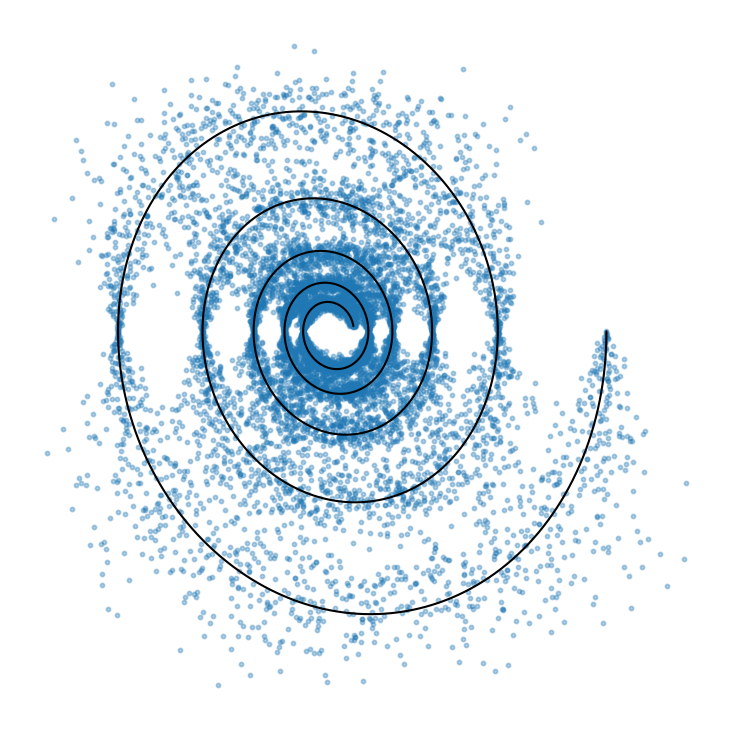

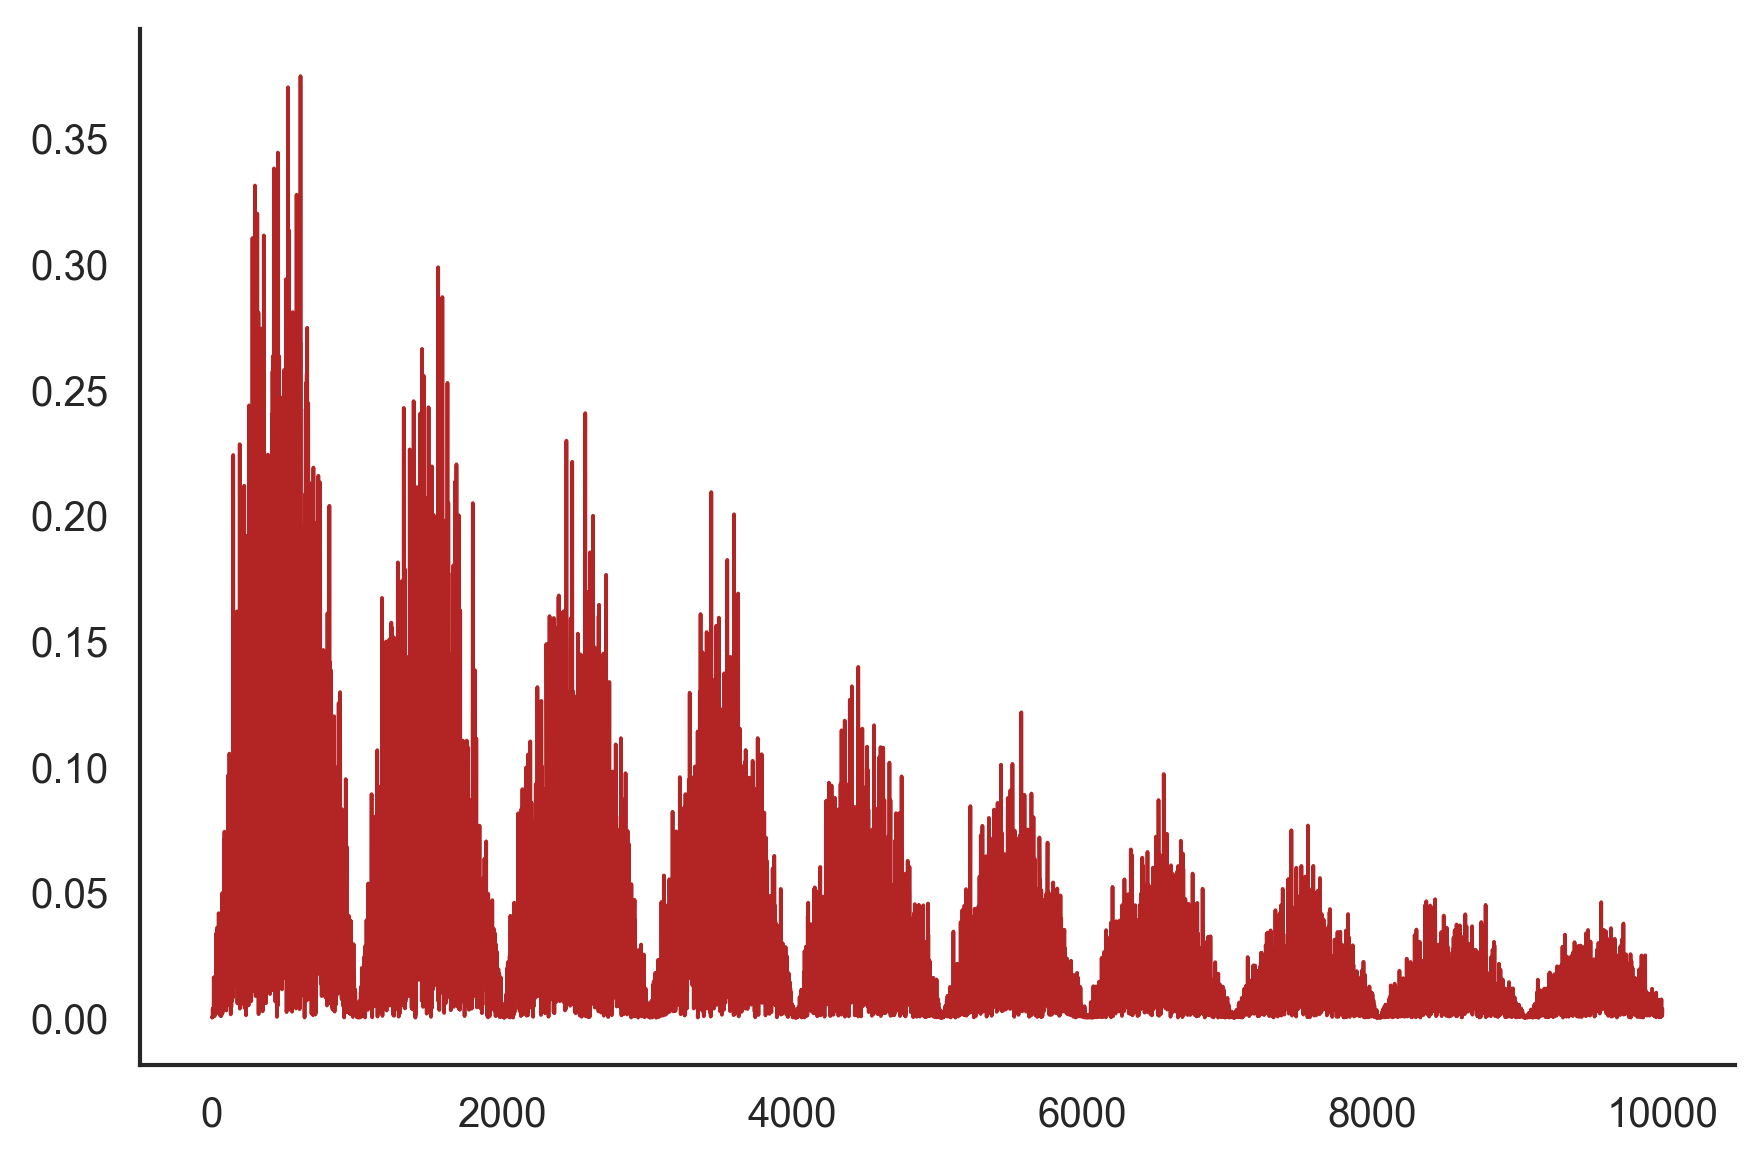

In [2]:
from mfsindy.cases.pendulum import simulate_pendulum_trajectory
from mfsindy.cases.pendulum_plots import plot_trajectories_additive_noise, plot_residuals

y0 = np.array([0.5, 0.0])
t_eval, Y_true = simulate_pendulum_trajectory(
    y0=y0,
    T=cfg.t1 - cfg.t0,
    dt=cfg.dt,
    g=cfg.g,
    L=cfg.L,
    c=cfg.c,
    noise_level=0.0,
    seed=0,
)
Y_noisy = plot_trajectories_additive_noise(
    x_true=Y_true,
    alpha=cfg.alpha,
    sigma0=cfg.sigma0,
)
plot_residuals(Y_true, Y_noisy)


## Hyperparameter Selection

Use one noisy pendulum trajectory realisation, split it 80-20 in time, tune the weak-form hyperparameters by maximizing held-out rollout $R^2$ for `Variance GLS`, then refit all three models on that same trajectory and print the resulting equations.


In [3]:
# SEARCH_GRID = {
#     "stlsq_threshold": [0.05, 0.1, 0.2],
#     "poly_degree": [1],
#     "H_xt": [0.005, 0.01, 0.025],
# }

# search_y0 = np.array([0.6, -0.2])
# t_search, Y_clean_search = simulate_pendulum_trajectory(
#     y0=search_y0,
#     T=cfg.t1 - cfg.t0,
#     dt=cfg.dt,
#     g=cfg.g,
#     L=cfg.L,
#     c=cfg.c,
#     noise_level=0.0,
#     seed=cfg.seed_base,
# )
# variance_search = np.maximum((cfg.sigma0 + cfg.alpha * np.abs(Y_clean_search[:, 0])) ** 2, 1e-10)
# rng_search = np.random.default_rng(cfg.seed_base + 123)
# Y_noisy_search = Y_clean_search + np.sqrt(variance_search)[:, None] * rng_search.standard_normal(size=Y_clean_search.shape)

# Y_train, Y_val, t_train, t_val = split_single_trajectory(
#     Y_noisy_search,
#     t_search,
#     validation_fraction=0.2,
# )
# variance_train = variance_search[: Y_train.shape[0]]
# methods = ["No weighting", "Variance GLS", "Ones GLS"]
# state_names = ("theta", "omega")

# def evaluate_candidate(candidate_cfg):
#     artifacts = build_polynomial_intra_trajectory_artifacts(
#         Y_train,
#         t_train,
#         variance=variance_train,
#         poly_degree=candidate_cfg.poly_degree,
#         derivative_order=candidate_cfg.derivative_order,
#         include_bias=candidate_cfg.include_bias,
#         K=candidate_cfg.K,
#         H_xt=candidate_cfg.H_xt,
#         p=candidate_cfg.p,
#         weak_seed=candidate_cfg.seed_base + 40_000,
#     )
#     fitted_models = fit_intra_trajectory_gls_model_objects(candidate_cfg, artifacts, methods)
#     rollout_models = build_polynomial_rollout_models(
#         {name: np.asarray(model.optimizer.coef_) for name, model in fitted_models.items()},
#         poly_degree=candidate_cfg.poly_degree,
#         reference_trajectory=Y_train,
#         state_names=state_names,
#         include_bias=candidate_cfg.include_bias,
#     )
#     return evaluate_rollout_models(rollout_models, [Y_val], t_grid=t_val)

# search_results = {}
# best_params_by_model = {}
# tuned_cfg_by_model = {}
# tuned_models = {}

# for target_model in methods:
#     search = optimize_hyperparams(
#         cfg,
#         param_grid=SEARCH_GRID,
#         evaluate=evaluate_candidate,
#         score_fn=make_metric_scorer(source=target_model, metric="rollout_r2"),
#         maximize=True,
#     )
#     tuned_cfg = deepcopy(search.best_config)
#     search_results[target_model] = search
#     best_params_by_model[target_model] = search.best_params
#     tuned_cfg_by_model[target_model] = tuned_cfg
#     full_artifacts = build_polynomial_intra_trajectory_artifacts(
#         Y_noisy_search,
#         t_search,
#         variance=variance_search,
#         poly_degree=tuned_cfg.poly_degree,
#         derivative_order=tuned_cfg.derivative_order,
#         include_bias=tuned_cfg.include_bias,
#         K=tuned_cfg.K,
#         H_xt=tuned_cfg.H_xt,
#         p=tuned_cfg.p,
#         weak_seed=tuned_cfg.seed_base + 40_001,
#     )
#     full_fitted_models = fit_intra_trajectory_gls_model_objects(tuned_cfg, full_artifacts, methods)
#     tuned_models[target_model] = build_polynomial_rollout_models(
#         {name: np.asarray(model.optimizer.coef_) for name, model in full_fitted_models.items()},
#         poly_degree=tuned_cfg.poly_degree,
#         reference_trajectory=Y_noisy_search,
#         state_names=state_names,
#         include_bias=tuned_cfg.include_bias,
#     )[target_model]

# print(pd.DataFrame(best_params_by_model).T)
# print(format_model_equations(tuned_models, precision=3))


## Run

In [4]:
# methods = ["No weighting", "Variance GLS", "Ones GLS"]
# df_errors_parts = []
# for method_name in methods:
#     method_cfg = deepcopy(tuned_cfg_by_model[method_name])
#     method_cfg.results_filename = f"pendulum_part2_{method_name.lower().replace(' ', '_')}.csv"
#     df_method, _, _ = run_pendulum_intra_trajectory_gls_experiment(method_cfg)
#     df_errors_parts.append(df_method[df_method["method"] == method_name].copy())

# df_errors = pd.concat(df_errors_parts, ignore_index=True)
# errors_path = os.path.join(cfg.results_dir, cfg.results_filename)
# df_errors.to_csv(errors_path, index=False)


## Errors

In [5]:
methods = ["No weighting", "Variance GLS", "Ones GLS"]


errors_path = os.path.join(cfg.results_dir, cfg.results_filename)
df_errors = pd.read_csv(errors_path)

L1_errors = {
    m: df_errors[(df_errors["method"] == m) & (df_errors["metric"] == "L1")]["value"].to_numpy()
    for m in methods
}
L0_errors = {
    m: df_errors[(df_errors["method"] == m) & (df_errors["metric"] == "L0")]["value"].to_numpy()
    for m in methods
}

print(f"Running heteroscedastic pendulum GLS experiment with {cfg.n_runs} runs.")

print("\nL1 errors (first few, reloaded from CSV):")
for m in methods:
    print(m, np.median(L1_errors[m]))

print("\nL0 support errors (first few, reloaded from CSV):")
for m in methods:
    print(m, np.median(L0_errors[m]))


Running heteroscedastic pendulum GLS experiment with 25 runs.

L1 errors (first few, reloaded from CSV):
No weighting 0.0106693080844302
Variance GLS 0.0041077495982913
Ones GLS 0.0106642488555944

L0 support errors (first few, reloaded from CSV):
No weighting 0.0
Variance GLS 0.0
Ones GLS 0.0


## L1 Error

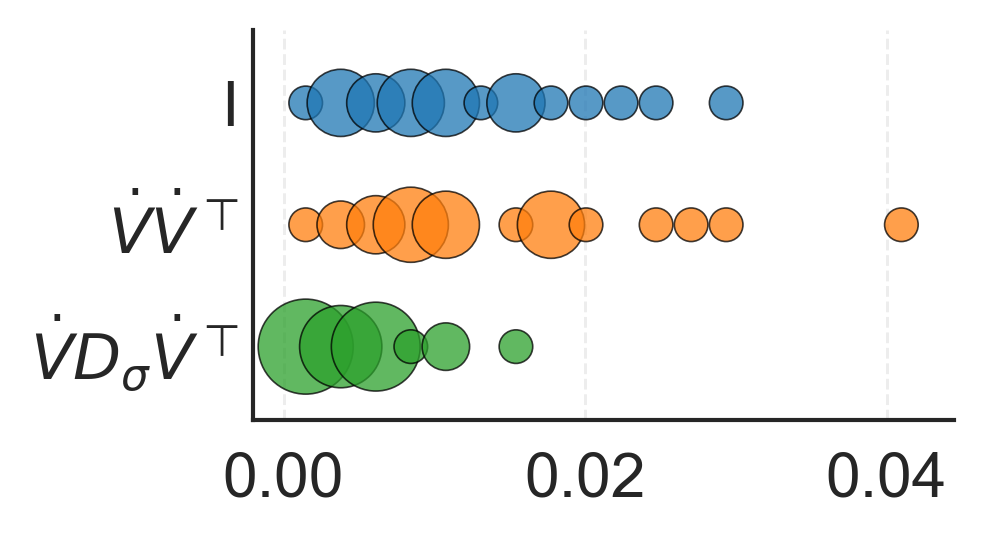

In [ ]:
method_colors = {
    "No weighting": "tab:blue",
    "Variance GLS": "tab:green",
    "Ones GLS": "tab:orange",
}
methods = ["Variance GLS", "Ones GLS", "No weighting"]
labels = [r"$\dot{V}D_\sigma\dot{V}^\top$",r"$\dot{V}\dot{V}^\top$","I"]

all_l1_values = np.concatenate([
    np.asarray(L1_errors[m], dtype=float)
    for m in methods
])

xmin = float(np.min(all_l1_values))-0.001
xmax = float(np.max(all_l1_values))+0.001
pad = 0.05 * (xmax - xmin if xmax > xmin else 1.0)

l1_xlim = (xmin - pad, xmax + pad)

bubble_hist(
    errors_dict=L1_errors,
    n_bins=20,
    models_order=methods,
    colors=method_colors,
    labels=labels,
    xlim=l1_xlim,
    save_path="results/l1_2",
)


## L0 Error

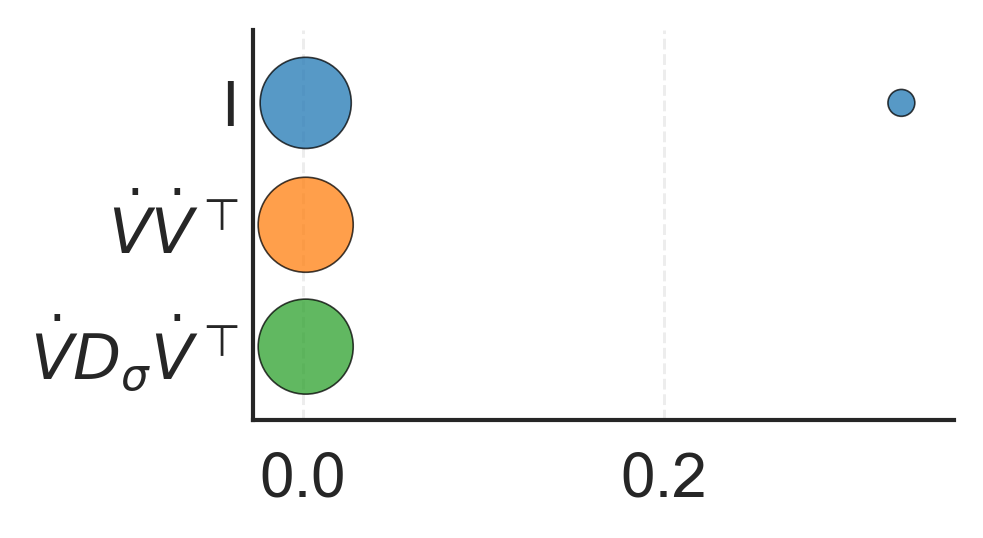

In [7]:
all_l0_values = np.concatenate([
    np.asarray(L0_errors[m], dtype=float)
    for m in methods
])

xmin = float(np.min(all_l0_values))-0.01
xmax = float(np.max(all_l0_values))+0.01

pad = 0.05 * (xmax - xmin if xmax > xmin else 1.0)
l0_xlim = (xmin - pad, xmax + pad)

bubble_hist(
    errors_dict=L0_errors,
    n_bins=20,
    models_order=methods,
    colors=method_colors,
    labels=labels,
    xlim=l0_xlim,
    save_path="results/l0_2"
)
